In [31]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

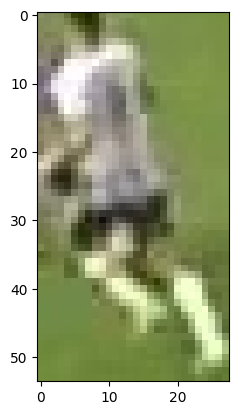

In [43]:
image = cv2.imread("screenshots/player_crop.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.show()

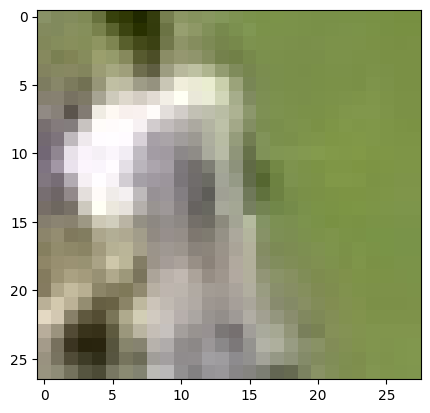

In [44]:

crop_img = image[0:int(image.shape[0])//2, :]
plt.imshow(crop_img)

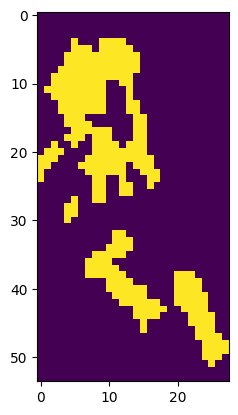

In [45]:
image_2d = image.reshape(-1,3)
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

labals = kmeans.labels_
clustered_image = labals.reshape(image.shape[0], image.shape[1])
plt.imshow(clustered_image)

In [46]:
corner_clustered_image = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(corner_clustered_image, key=corner_clustered_image.count)
print(non_player_cluster)

0


In [48]:
player_cluster = 1 - non_player_cluster
player_color = kmeans.cluster_centers_[player_cluster]
print(player_color)

[196.43251534 197.54294479 172.73312883]


In [47]:
def CheckPlayerColor(crop_frame):
    crop_img = image[0:int(crop_frame.shape[0])//2, :]
    image_2d = image.reshape(-1,3)
    kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

    labals = kmeans.labels_
    clustered_image = labals.reshape(image.shape[0], image.shape[1])

    corner_clustered_image = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0],
                          clustered_image[-1, -1]]
    non_player_cluster = max(corner_clustered_image, key=corner_clustered_image.count)
    player_cluster = 1 - non_player_cluster

    player_color = kmeans.cluster_centers_[player_cluster]
    return player_color


